<a href="https://colab.research.google.com/github/Faspeice/ml/blob/lr6/lr6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 6

# Деревья решений и ансамбли на их основе

**Цель работы**: научиться решать задачу классификации методами
решающих деревьев и ансамблей на их основе.

Выполним анализ набора данных `customer_churn`. Набор представляет собой данные об активности клиентов маректинговой компании. Смысл задачи - определять, основываясь на этих данных, уйдет клиент, за которым был закрееплен менеджер, или нет. Набор данных включает следующие атрибуты:

- **Name** – имя последнего контактного лица в компании.  
- **Age** – возраст клиента.  
- **Total Purchase** – общее количество купленных объявлений.  
- **Account Manager** – двоичный код (0 – нет менеджера, 1 – назначен менеджер по работе с клиентами).  
- **Years** – всего лет в качестве клиента.  
- **Num sites** – число веб-сайтов, которые используют сервис.  
- **Onboard date** – дата, когда имя последнего контактного лица было указано в boarded.  
- **Location** – адрес штаб-квартиры клиента.  
- **Company** – название компании-клиента.  
- **Churn** – ушел или нет (целевая переменная).

 ## Импорт необходимых библиотек

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

 ## Загрузка и первичный анализ данных



In [30]:
url = "https://raw.githubusercontent.com/faspeice/ml/lr6/customer_churn.csv"
data = pd.read_csv(url)

# Оставляем только клиентов, которым был назначен менедер
data = data[data['Account_Manager'] == 1].copy()
data.drop(columns=['Account_Manager'], inplace = True)

print("Общая размерность данных:", data.shape)
print("Названия всех столбцов:", data.columns.tolist())
print("Уникальные значения в целевой переменной:", data['Churn'].unique())
print("\nПервые 5 строк данных:")
print(data.head())

Общая размерность данных: (433, 9)
Названия всех столбцов: ['Names', 'Age', 'Total_Purchase', 'Years', 'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn']
Уникальные значения в целевой переменной: [1 0]

Первые 5 строк данных:
             Names   Age  Total_Purchase  Years  Num_Sites  \
6      Eric Butler  44.0        11331.58   5.23       11.0   
7    Zachary Walsh  32.0         9885.12   6.92        9.0   
8      Ashlee Carr  43.0        14062.60   5.46       11.0   
9   Jennifer Lynch  40.0         8066.94   7.11       11.0   
10    Paula Harris  30.0        11575.37   5.22        8.0   

           Onboard_date                                           Location  \
6   2016-12-05 03:35:43      4846 Savannah Road West Justin, IA 87713-3460   
7   2006-03-09 14:50:20  25271 Roy Expressway Suite 147 Brownport, FM 5...   
8   2011-09-29 05:47:23  3725 Caroline Stravenue South Christineview, M...   
9   2006-03-28 15:42:45  363 Sandra Lodge Suite 144 South Ann, WI 51655...   
1

## Исключаем невлияющие категориальные признаки

Проверим категориальные признаки на уникальность

In [31]:
print(data['Names'].nunique())
print(data['Location'].nunique())
print(data['Company'].nunique())
print(data['Onboard_date'].nunique())

433
433
425
433


Можно сделать вывод, что категорриальные признаки Names, Location и Onboard_date не будут влиять на что либо и их можно смело удалить

In [32]:
data.drop(['Names','Location','Onboard_date'],axis = 1, inplace = True)
data.head()

,Age,Total_Purchase,Years,Num_Sites,Company,Churn
6,44.0,11331.58,5.23,11.0,Reynolds-Sheppard,1
7,32.0,9885.12,6.92,9.0,Singh-Cole,1
8,43.0,14062.60,5.46,11.0,Lopez PLC,1
9,40.0,8066.94,7.11,11.0,Reed-Martinez,1
10,30.0,11575.37,5.22,8.0,"Briggs, Lamb and Mathews",1


Преобразуем оставшиеся категориальные признаки в числовые

In [33]:
labelencoder_c = LabelEncoder()
data['Company'] = labelencoder_c.fit_transform(data['Company'])

data.head()

,Age,Total_Purchase,Years,Num_Sites,Company,Churn
6,44.0,11331.58,5.23,11.0,292,1
7,32.0,9885.12,6.92,9.0,331,1
8,43.0,14062.60,5.46,11.0,221,1
9,40.0,8066.94,7.11,11.0,287,1
10,30.0,11575.37,5.22,8.0,32,1


## Разделение данных на обучающую и тестовую выборки

In [34]:
y = data['Churn']
X = data.drop('Churn', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

print(f"Размер обчающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обчающей выборки: (346, 5)
Размер тестовой выборки: (87, 5)


,Age,Total_Purchase,Years,Num_Sites,Company,Churn
6,44.0,11331.58,5.23,11.0,292,1
7,32.0,9885.12,6.92,9.0,331,1
8,43.0,14062.60,5.46,11.0,221,1
9,40.0,8066.94,7.11,11.0,287,1
10,30.0,11575.37,5.22,8.0,32,1


## Построение и оценка базового дерева решений

In [35]:
base_dt = DecisionTreeClassifier(random_state=42)
base_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [36]:
# Делаем прогнозы
y_pred_base = base_dt.predict(X_test)

# Оцениваем точность
accuracy_base = accuracy_score(y_test, y_pred_base)
print(f"Точность базового дерева на тесте: {accuracy_base:.4f}")

Точность базового дерева на тесте: 0.8391


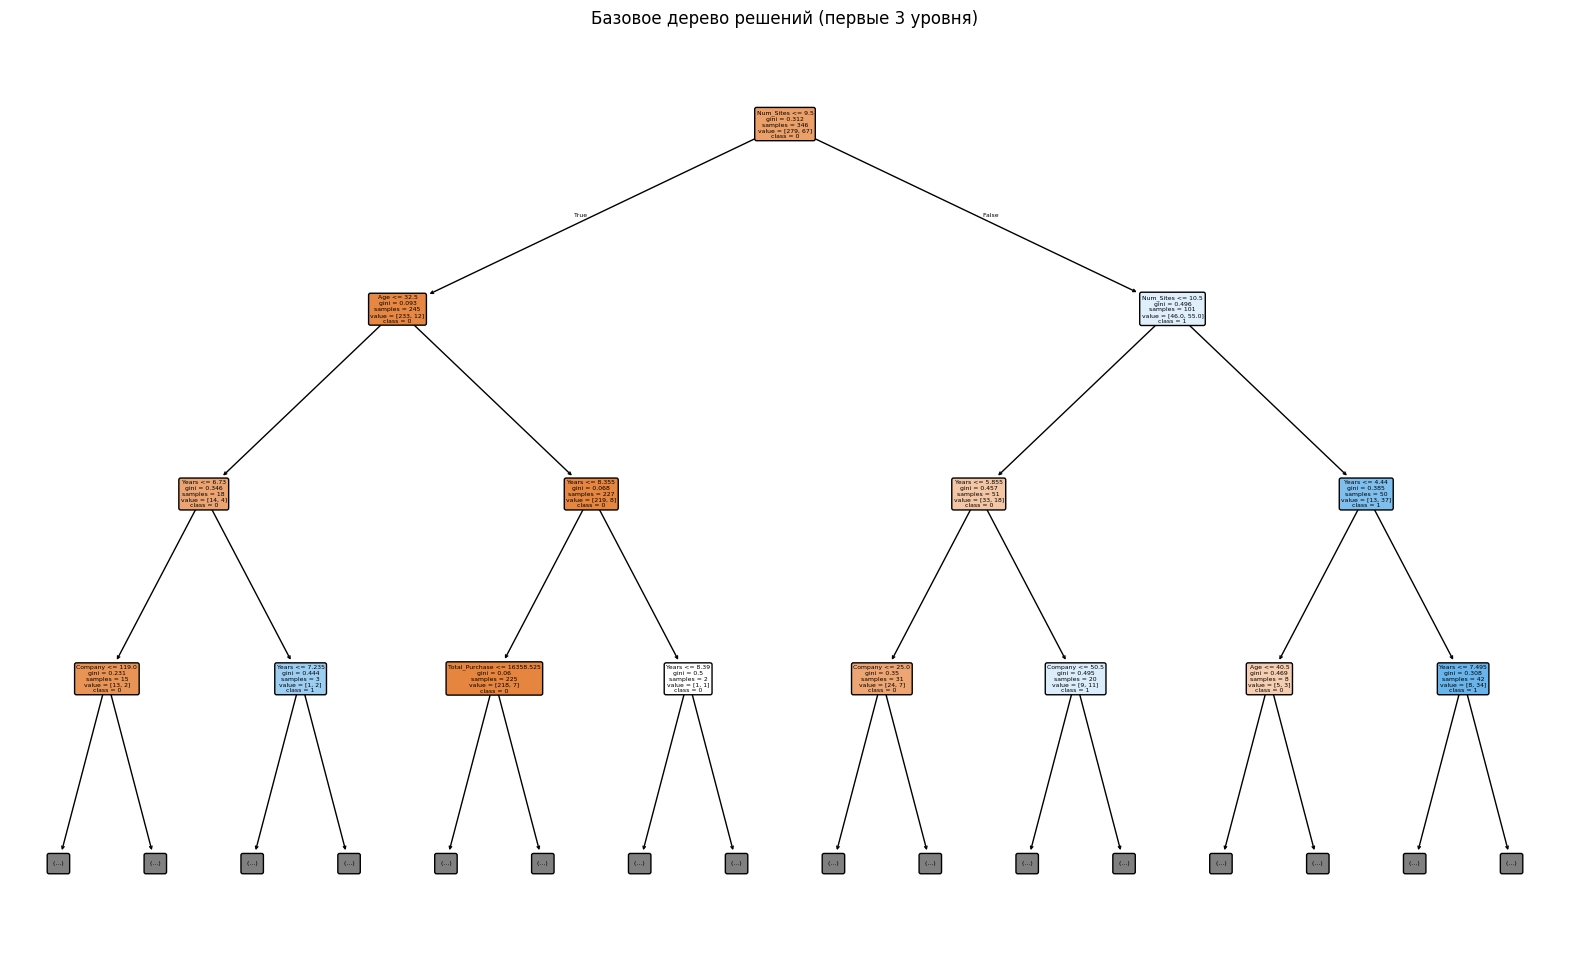

In [37]:
feature_names = X.columns.tolist()
class_names = sorted(y.astype(str).unique())

plt.figure(figsize=(20, 12))
plot_tree(base_dt,
          filled=True,
          feature_names=feature_names,
          class_names=class_names,
          rounded=True,
          max_depth=3)
plt.title("Базовое дерево решений (первые 3 уровня)")
plt.show()

## Борьба с переобучением: настройка гиперпараметров

In [38]:
# Попробуем ограничить глубину дерева
tuned_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
tuned_dt.fit(X_train, y_train)

y_pred_tuned = tuned_dt.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Точность настроенного дерева (max_depth=3) на тесте: {accuracy_tuned:.4f}")

Точность настроенного дерева (max_depth=3) на тесте: 0.9195


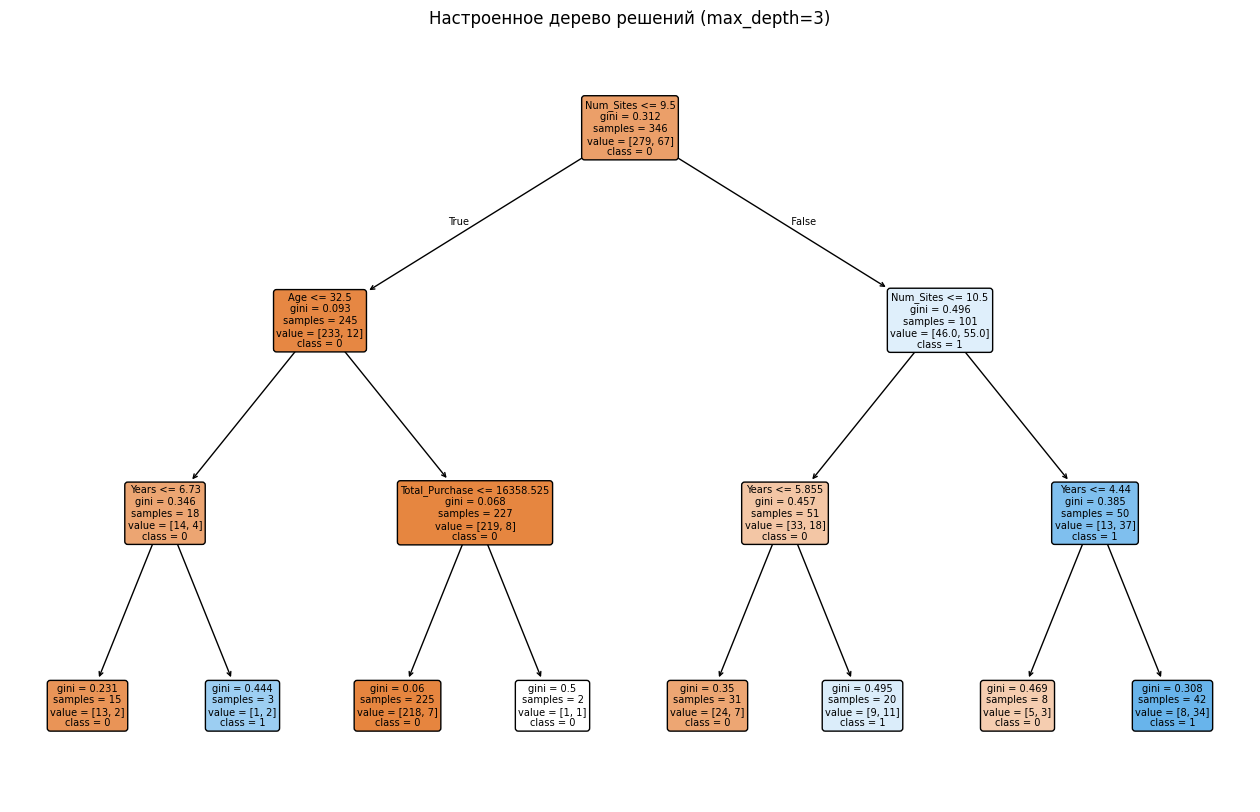

In [39]:
plt.figure(figsize=(16, 10))
plot_tree(tuned_dt, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
plt.title("Настроенное дерево решений (max_depth=3)")
plt.show()

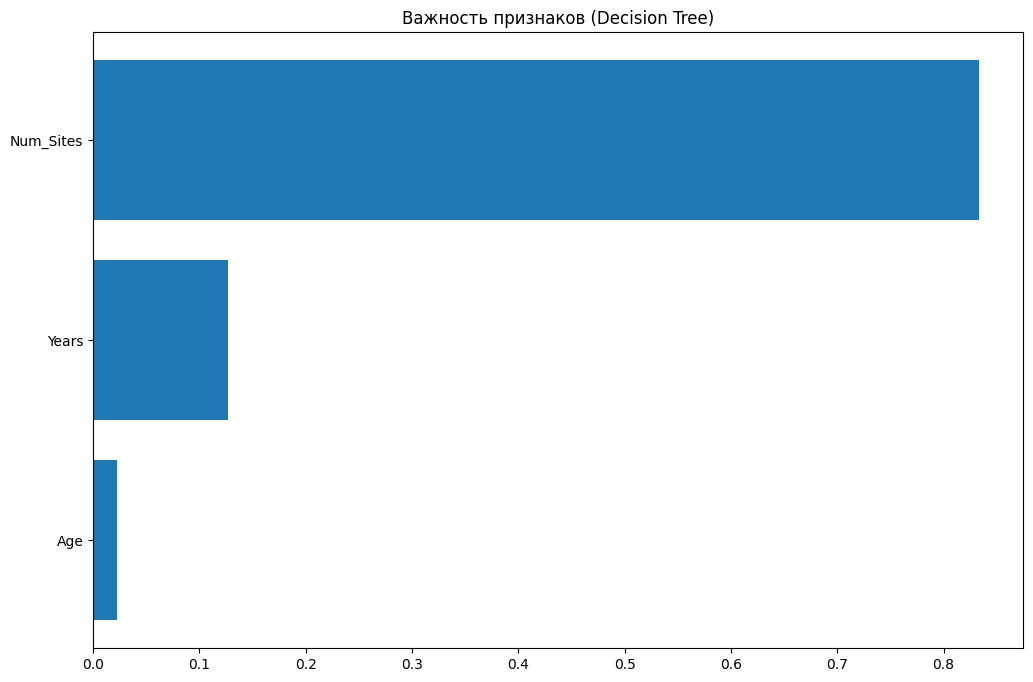

In [40]:
# Важность признаков
importances = tuned_dt.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Важность признаков (Decision Tree)")
plt.barh(range(3), importances[indices][:3]) # Топ-3 признака
plt.yticks(range(3), [X.columns[i] for i in indices[:3]])
plt.gca().invert_yaxis()
plt.show()

In [41]:
# Создаем и обучаем случайный лес
rf = RandomForestClassifier(n_estimators=100, random_state=42)  # 100 деревьев
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [42]:
# Прогноз и оценка
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Точность Случайного леса на тесте: {accuracy_rf:.4f}")

Точность Случайного леса на тесте: 0.8851


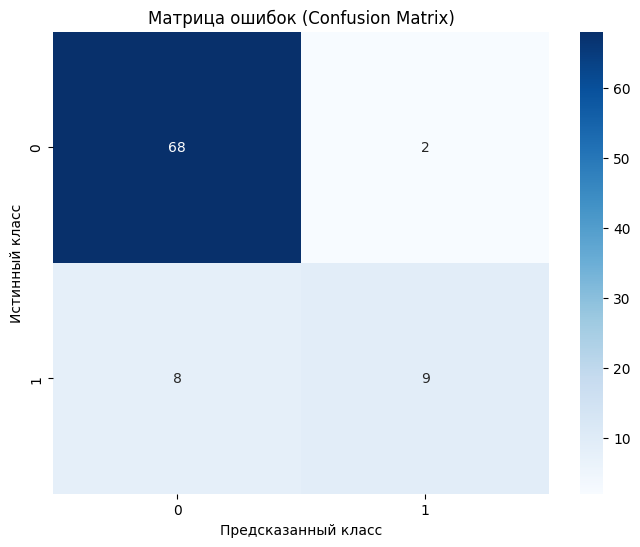

In [43]:
# Строим матрицу ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

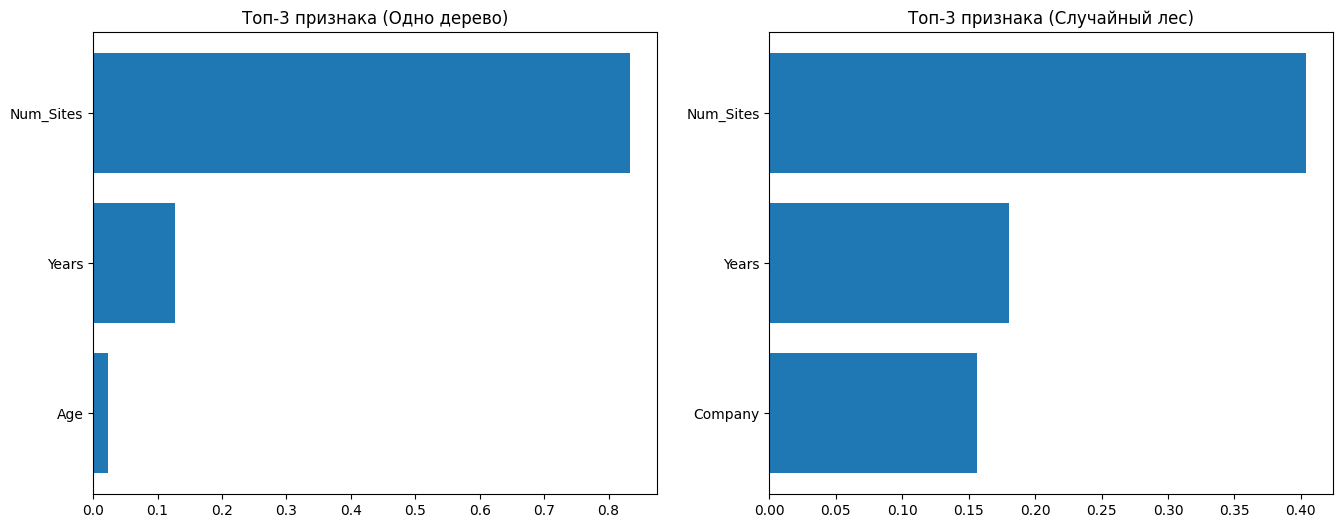

In [44]:
# Сравним важность признаков с одиночным деревом (топ-3)
rf_importances = rf.feature_importances_
indices_rf = np.argsort(rf_importances)[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(range(3), importances[indices][:3])
ax1.set_title("Топ-3 признака (Одно дерево)")
ax1.set_yticks(range(3))
ax1.set_yticklabels([X.columns[i] for i in indices[:3]])
ax1.invert_yaxis()

ax2.barh(range(3), rf_importances[indices_rf][:3])
ax2.set_title("Топ-3 признака (Случайный лес)")
ax2.set_yticks(range(3))
ax2.set_yticklabels([X.columns[i] for i in indices_rf[:3]])
ax2.invert_yaxis()

plt.show()

## Подбор гиперпараметров случайного дерева

In [45]:
from sklearn.model_selection import GridSearchCV

# Определяем сетку параметров для перебора
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Создаём модель для поиска
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Запускаем поиск
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [46]:
# Выводим лучшие параметры
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность при кросс-валидации: {:.4f}".format(grid_search.best_score_))

# Оцениваем лучшую модель на тестовых данных
best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Точность улучшенной модели на тестовой выборке: {best_accuracy:.4f}")

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Лучшая точность при кросс-валидации: 0.8757
Точность улучшенной модели на тестовой выборке: 0.8851


## Ансамбли: Градиентный бустинг

In [47]:
# Создаем и обучаем Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [48]:
# Прогноз и оценка
y_pred_gb = gb.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Точность Gradient Boosting на тесте: {accuracy_gb:.4f}")

Точность Gradient Boosting на тесте: 0.8966


## Сравнение всех моделей

In [49]:
# Создаем сводную таблицу результатов
models = {
    'Base Decision Tree': base_dt,
    'Tuned Decision Tree': tuned_dt,
    'Random Forest': best_rf_model,
    'Gradient Boosting': gb
}

results = {}
for name, model in models.items():
    # Считаем accuracy на тренировочном и тестовом наборах
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = {'Train Accuracy': train_acc, 'Test Accuracy': test_acc}

                     Train Accuracy  Test Accuracy
Base Decision Tree         1.000000       0.839080
Tuned Decision Tree        0.890173       0.919540
Random Forest              0.950867       0.885057
Gradient Boosting          0.988439       0.896552


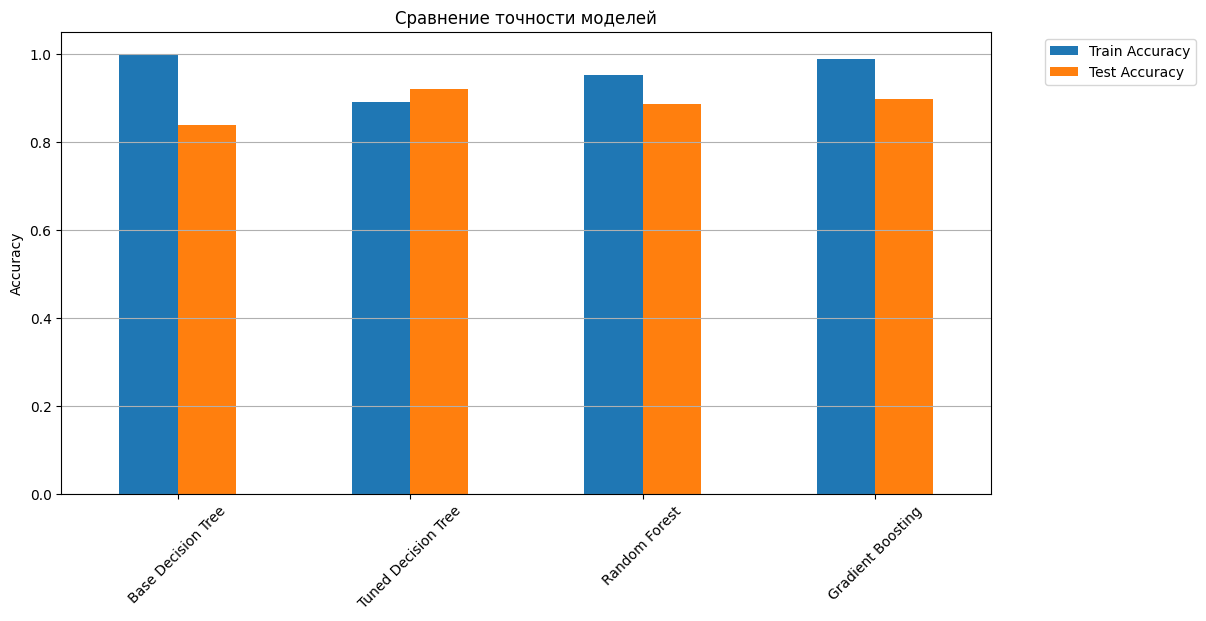

In [50]:
# Выводим результаты в виде DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

# Строим bar-plot для наглядности
results_df[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(12, 6))
plt.title("Сравнение точности моделей")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.show()